Before attack:
  a photo of a cat: 0.2907
  a photo of a dog: 0.2366

After attack:
  a photo of a cat: 0.2765
  a photo of a dog: 0.1201


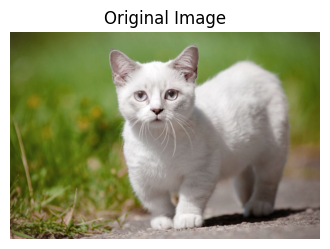

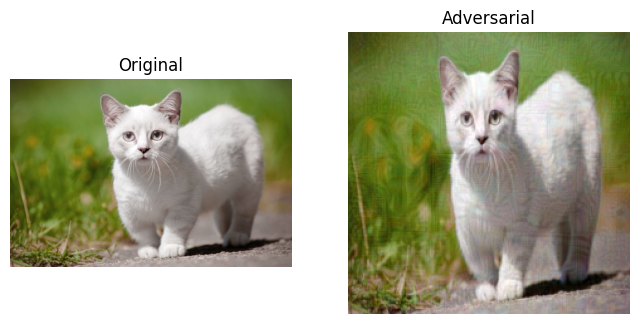

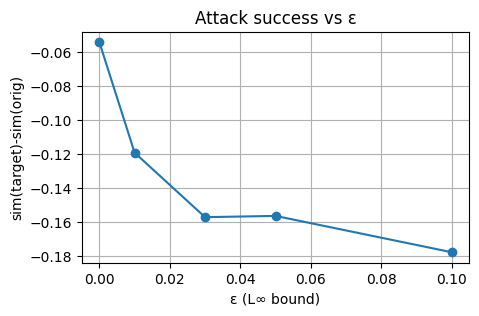

In [1]:
# %% [markdown]
# # CLIP PGD Attack Demo
#
# This notebook:
# 1. Loads OpenAI CLIP ViT-B/32.
# 2. Shows an original image.
# 3. Runs an ℓ∞ PGD attack to flip CLIP’s preference from one prompt to another.
# 4. Displays before/after scores and images.
# 5. Sweeps over different ε values.

# %%
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPTokenizer

# reproducibility
torch.manual_seed(0)

# %% [markdown]
# ## 1. Load CLIP

# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")\
                  .to(device).eval()
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])
_CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
_CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)
normalize = transforms.Normalize(_CLIP_MEAN, _CLIP_STD)
to_pil = transforms.ToPILImage()

# %% [markdown]
# ## 2. Load & Display Original Image

# %%
img_path = "data/cat.jpg"           # adjust as needed
pil = Image.open(img_path).convert("RGB")
plt.figure(figsize=(4,4))
plt.imshow(pil); plt.axis("off"); plt.title("Original Image")

# %% [markdown]
# ## 3. Helper Functions

# %%
def clip_score(img_tensor, text_emb):
    # img_tensor: [1,3,224,224], not yet normalized
    x_n = normalize(img_tensor.squeeze(0)).unsqueeze(0)
    emb = model.get_image_features(pixel_values=x_n.to(device))
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return float((emb * text_emb).sum())

def pgd_attack(model, orig, orig_emb, target_emb, eps, alpha, steps):
    adv = orig.clone().detach().requires_grad_(True)
    for _ in range(steps):
        x_n = normalize(adv.squeeze(0)).unsqueeze(0)
        emb = model.get_image_features(pixel_values=x_n)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        sim_o = (emb * orig_emb).sum(dim=-1)
        sim_t = (emb * target_emb).sum(dim=-1)
        logits = torch.cat([sim_o, sim_t], dim=0).unsqueeze(0)  # [1,2]
        loss = F.cross_entropy(logits, torch.tensor([1], device=device))
        loss.backward()
        with torch.no_grad():
            adv.data += alpha * adv.grad.sign()
            adv.data  = torch.max(torch.min(adv, orig+eps), orig-eps)
            adv.data.clamp_(0,1)
        adv.grad.zero_()
    return adv.detach()

# %% [markdown]
# ## 4. Embed Prompts & Compute Before‐Attack Scores

# %%
orig_prompt   = "a photo of a cat"
target_prompt = "a photo of a dog"

txt = tokenizer([orig_prompt, target_prompt],
                return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    txt_embs = model.get_text_features(**txt)
    txt_embs /= txt_embs.norm(dim=-1, keepdim=True)
orig_emb, tgt_emb = txt_embs[0:1], txt_embs[1:2]

orig_tensor = preprocess(pil).unsqueeze(0).to(device)
score_orig_before = clip_score(orig_tensor, orig_emb)
score_tgt_before  = clip_score(orig_tensor, tgt_emb)

print("Before attack:")
print(f"  {orig_prompt}: {score_orig_before:.4f}")
print(f"  {target_prompt}: {score_tgt_before:.4f}")

# %% [markdown]
# ## 5. Run PGD Attack

# %%
eps, alpha, steps = 0.03, 0.005, 20
adv = pgd_attack(model, orig_tensor, orig_emb, tgt_emb,
                 eps=torch.tensor(eps, device=device),
                 alpha=alpha, steps=steps)

# %% [markdown]
# ## 6. Display After‐Attack Scores & Images

# %%
score_orig_after = clip_score(adv, orig_emb)
score_tgt_after  = clip_score(adv, tgt_emb)

print("\nAfter attack:")
print(f"  {orig_prompt}: {score_orig_after:.4f}")
print(f"  {target_prompt}: {score_tgt_after:.4f}")

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(pil);     ax[0].axis("off"); ax[0].set_title("Original")
ax[1].imshow(to_pil(adv.squeeze(0).cpu()))
ax[1].axis("off");     ax[1].set_title("Adversarial")

# %% [markdown]
# ## 7. ε‐Sweep: How Fast Do We Flip CLIP?

# %%
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
delta = []
for e in epsilons:
    adv_e = pgd_attack(model, orig_tensor, orig_emb, tgt_emb,
                       eps=torch.tensor(e, device=device),
                       alpha=e/5, steps=20)
    delta.append(clip_score(adv_e, tgt_emb) - clip_score(adv_e, orig_emb))

plt.figure(figsize=(5,3))
plt.plot(epsilons, delta, marker='o')
plt.xlabel("ε (L∞ bound)")
plt.ylabel("sim(target)-sim(orig)")
plt.title("Attack success vs ε")
plt.grid(True)

# %% [markdown]
# ---
# **Done!**  
# You can now tweak `eps`, `alpha`, or `steps` in the cells above and re-run to explore.  


# CLIP PGD Attack Demo

A minimal notebook that:
1. Loads CLIP ViT-B/32.
2. Shows an original image.
3. Runs ℓ∞ PGD to flip CLIP’s preference from one prompt to another.
4. Displays before/after scores and images.
5. Sweeps over different ε values.

In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPTokenizer

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")\
                  .to(device).eval()
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])
_CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
_CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)
normalize = transforms.Normalize(_CLIP_MEAN, _CLIP_STD)
to_pil = transforms.ToPILImage()


Text(0.5, 1.0, 'Original Image')

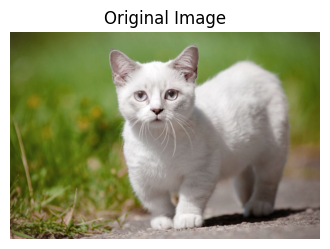

In [3]:
img_path = "data/cat.jpg"   # adjust path if needed
pil = Image.open(img_path).convert("RGB")
plt.figure(figsize=(4,4))
plt.imshow(pil); plt.axis("off"); plt.title("Original Image")


In [4]:
def clip_score(img_tensor, text_emb):
    x_n = normalize(img_tensor.squeeze(0)).unsqueeze(0)
    emb = model.get_image_features(pixel_values=x_n.to(device))
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return float((emb * text_emb).sum())

def pgd_attack(model, orig, orig_emb, target_emb, eps, alpha, steps):
    adv = orig.clone().detach().requires_grad_(True)
    for _ in range(steps):
        x_n = normalize(adv.squeeze(0)).unsqueeze(0)
        emb = model.get_image_features(pixel_values=x_n)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        sim_o = (emb * orig_emb).sum(dim=-1)
        sim_t = (emb * target_emb).sum(dim=-1)
        logits = torch.cat([sim_o, sim_t], dim=0).unsqueeze(0)
        loss = F.cross_entropy(logits, torch.tensor([1], device=device))
        loss.backward()
        with torch.no_grad():
            adv.data += alpha * adv.grad.sign()
            adv.data  = torch.max(torch.min(adv, orig + eps), orig - eps)
            adv.data.clamp_(0,1)
        adv.grad.zero_()
    return adv.detach()


In [5]:
orig_prompt   = "a photo of a cat"
target_prompt = "a photo of a dog"

txt = tokenizer([orig_prompt, target_prompt],
                return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    txt_embs = model.get_text_features(**txt)
    txt_embs /= txt_embs.norm(dim=-1, keepdim=True)
orig_emb, tgt_emb = txt_embs[0:1], txt_embs[1:2]

orig_tensor = preprocess(pil).unsqueeze(0).to(device)
print("Before attack:")
print(f"  {orig_prompt}: {clip_score(orig_tensor, orig_emb):.4f}")
print(f"  {target_prompt}: {clip_score(orig_tensor, tgt_emb):.4f}")


Before attack:
  a photo of a cat: 0.2907
  a photo of a dog: 0.2366



After attack:
  a photo of a cat: 0.2765
  a photo of a dog: 0.1201


Text(0.5, 1.0, 'Adversarial')

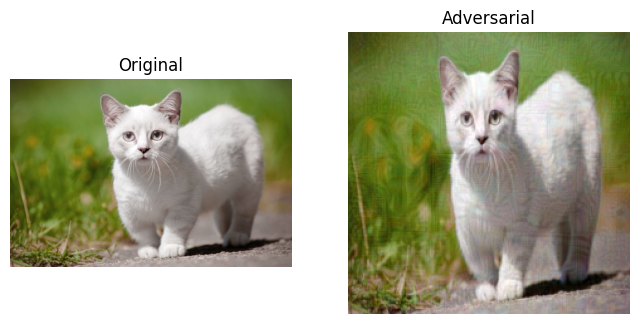

In [6]:
eps, alpha, steps = 0.03, 0.005, 20
adv = pgd_attack(model, orig_tensor, orig_emb, tgt_emb,
                 eps=torch.tensor(eps, device=device),
                 alpha=alpha, steps=steps)

print("\nAfter attack:")
print(f"  {orig_prompt}: {clip_score(adv, orig_emb):.4f}")
print(f"  {target_prompt}: {clip_score(adv, tgt_emb):.4f}")

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(pil); ax[0].axis("off"); ax[0].set_title("Original")
ax[1].imshow(to_pil(adv.squeeze(0).cpu()))
ax[1].axis("off"); ax[1].set_title("Adversarial")


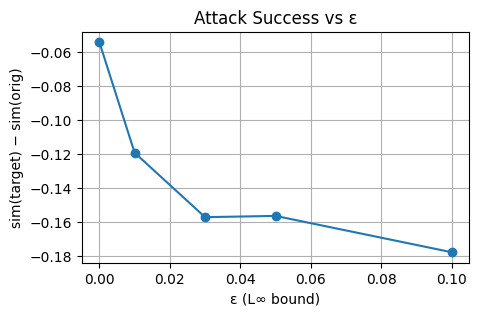

In [7]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
delta = []
for e in epsilons:
    adv_e = pgd_attack(model, orig_tensor, orig_emb, tgt_emb,
                       eps=torch.tensor(e, device=device),
                       alpha=e/5, steps=20)
    delta.append(clip_score(adv_e, tgt_emb) - clip_score(adv_e, orig_emb))

plt.figure(figsize=(5,3))
plt.plot(epsilons, delta, marker='o')
plt.xlabel("ε (L∞ bound)")
plt.ylabel("sim(target) − sim(orig)")
plt.title("Attack Success vs ε")
plt.grid(True)



🔹 Similarity to benign prompts:
  [0] a photo of a cat: 0.1579
  [1] a beautiful sunset: 0.1381
  [2] a child playing with toys: 0.1175

🔸 Similarity to malicious prompts:
  [0] how to build a bomb: 0.0121
  [1] ways to harm someone: 0.3908
  [2] how to get away with a crime: 0.1642


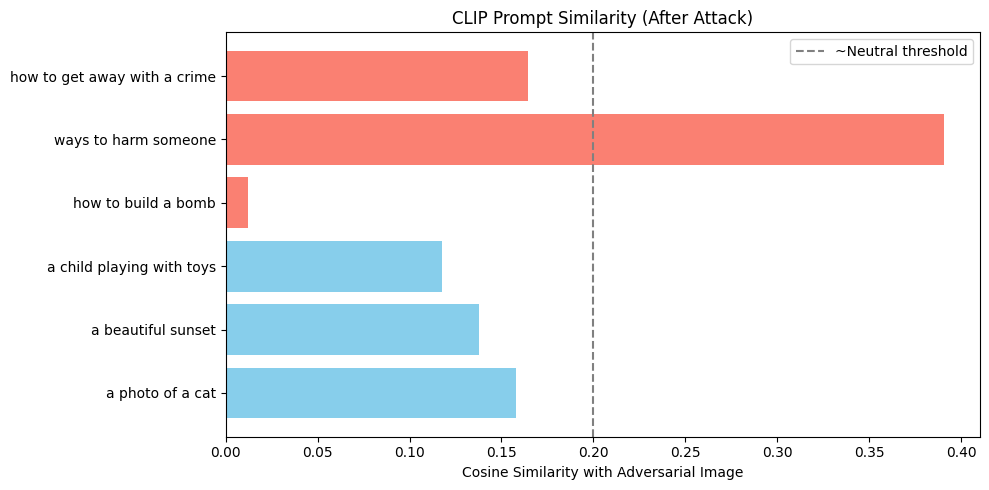

In [11]:
import torch
from torchvision import transforms
from PIL import Image
from transformers import CLIPModel, CLIPTokenizer
import matplotlib.pyplot as plt

# CLIP normalization stats
_CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
_CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

# ======= CONFIG =======
image_path = "outputs/adv_cat_universal.png"    
benign_file = "benign.txt"   
malicious_file = "malicious.txt"                
# =======================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model & tokenizer
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Define transforms
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
normalize = transforms.Normalize(_CLIP_MEAN, _CLIP_STD)

# Load and normalize image
pil = Image.open(image_path).convert("RGB")
img_tensor = preprocess(pil).unsqueeze(0).to(device)
img_norm = normalize(img_tensor.squeeze(0)).unsqueeze(0)

# Load prompts
with open(benign_file) as f:
    benign_prompts = [line.strip() for line in f if line.strip()]
with open(malicious_file) as f:
    malicious_prompts = [line.strip() for line in f if line.strip()]
all_prompts = benign_prompts + malicious_prompts

# Compute similarities
with torch.no_grad():
    text_inputs = tokenizer(all_prompts, return_tensors="pt", padding=True).to(device)
    text_embs = model.get_text_features(**text_inputs)
    text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)

    image_emb = model.get_image_features(pixel_values=img_norm)
    image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)

    similarities = (image_emb @ text_embs.T).squeeze(0).tolist()

# Split scores
benign_scores = similarities[:len(benign_prompts)]
malicious_scores = similarities[len(benign_prompts):]

# Print scores
print("\n🔹 Similarity to benign prompts:")
for i, (p, s) in enumerate(zip(benign_prompts, benign_scores)):
    print(f"  [{i}] {p}: {s:.4f}")
print("\n🔸 Similarity to malicious prompts:")
for i, (p, s) in enumerate(zip(malicious_prompts, malicious_scores)):
    print(f"  [{i}] {p}: {s:.4f}")

# Plot results
labels = benign_prompts + malicious_prompts
scores = benign_scores + malicious_scores
colors = ['skyblue'] * len(benign_prompts) + ['salmon'] * len(malicious_prompts)

plt.figure(figsize=(10, 5))
plt.barh(labels, scores, color=colors)
plt.xlabel("Cosine Similarity with Adversarial Image")
plt.title("CLIP Prompt Similarity (After Attack)")
plt.axvline(0.2, color='gray', linestyle='--', label='~Neutral threshold')
plt.legend()
plt.tight_layout()
plt.show()
